In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict,Literal
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [31]:
class X_post(TypedDict):
    topic:str
    content:str
    evlt:str
    opt:str
    

In [32]:
llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [33]:
def geneartor(state:X_post):
    prompt=f"write a post for the twitter on the topic {state['topic'] } the post was little bit funny and complete all requirement of the Twitter"
    response=llm.invoke(prompt).content
    return {"content":response}

In [44]:
def evalute(state: X_post):
     prompt = f"""You are an expert reviewer for X/Twitter posts. Evaluate the following post \n {state['content']} against the topic {state['topic']} and provide the ansere in only two word y for Yes and n for No
        """
     response=llm.invoke(prompt).content.lower()
     return {"evlt":response}
    

In [45]:
def optimizer(state:X_post):
    prompt=f"optimze this {state['content']} post which is suit able for this {state['topic']} and little bit funny"
    response =llm.invoke(prompt)
    return {"opt":response}

In [50]:
def check_condition(state:X_post) -> Literal["optimizer"]:
    if state['evlt']=="n":
        return "optimizer"
    else:
        return "Ok_post"


In [51]:
graph=StateGraph(X_post)

graph.add_node("generator",geneartor)
graph.add_node("Evlatue",evalute)
graph.add_node("optimizer",optimizer)

graph.add_edge(START,"generator")
graph.add_edge("generator","Evlatue")
graph.add_conditional_edges("Evlatue",check_condition,{"optimizer":"Evlatue","Ok_post":END})


workflow=graph.compile()




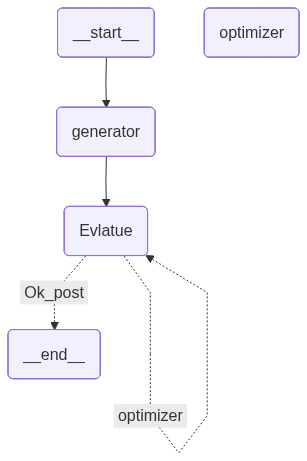

In [52]:
workflow

In [54]:
workflow.invoke({"topic":"Ai in 2016"})

{'topic': 'Ai in 2016',
 'content': 'Here\'s a funny Twitter post about AI in 2016, keeping all Twitter requirements in mind:\n\n---\n\n**Tweet:**\n\nIt\'s 2016! 🤖 AI is officially a genius, with AlphaGo beating the world\'s best Go player! 🤯 Meanwhile, my phone still thinks I want to call "barbecue" instead of "Barbara." Guess the robot uprising isn\'t *quite* ready yet. Or is it? 🤔😂\n\n#AI #2016 #AlphaGo #TechNostalgia #SiriProblems\n\n---',
 'evlt': 'y for yes'}